<a href="https://colab.research.google.com/github/FRIDA-34/EstadisticaVerano2026/blob/main/Copia_de_Problemas_Un_Factor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Analiza los siguientes diseños experimentales, e intenta sacar el máximo valor a la información. Verifica los supuestos (linealidad, homscedasticidad e independencia), puedes apoyarte en [la guía de la unidad 4](https://github.com/DrFaus/Estadistica2026B/blob/main/DiseniosExperimentalesUnFactor.ipynb). Aplica una prueba post-hoc en caso que sea necesario. Redacta una conclusión y una recomendación para las personas que recolectaron los datos.

1. **Comparación de cuatro métodos de ensamble:** Un equipo de mejora investiga el efecto de cuatro métodos de ensamble A, B, C y D, sobre el tiempo de ensamble en minutos. En primera instancia, la estrategia experimental es aplicar cuatro veces los cuatro métodos de ensamble en orden completamente aleatorio (las 16 pruebas en orden aleatorio). Los tiempos de ensamble obtenidos se muestran en la tabla 3.1. Si se usa el diseño completamente al azar (DCA), se supone que, además del método de ensamble, no existe ningún otro factor que influya de manera significativa sobre la variable de respuesta (tiempo de ensamble).

| Método de ensamble | A  | B  | C  | D  |
|--------------------|----|----|----|----|
|                    | 6  | 7  | 11 | 10 |
|                    | 8  | 9  | 16 | 12 |
|                    | 7  | 10 | 11 | 11 |
|                    | 8  | 8  | 13 | 9  |


In [1]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
metodo,minutos}
A,6
B,7
C,11
D,10
A,8
B,9
C,16
D,12
A,7
B,10
C,11
D,11
A,8
B,8
C,13
D,9
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,metodo,minutos}
0,A,6
1,B,7
2,C,11
3,D,10
4,A,8
5,B,9
6,C,16
7,D,12
8,A,7
9,B,10


anova

In [2]:
#FRIDA SARAHI VAZQUEZ RUIZ
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# Renombrar la columna 'minutos}' a 'minutos'
df = df.rename(columns={'minutos}': 'minutos'})

modelo = ols('minutos ~ C(metodo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(metodo),69.5,3.0,9.4237,0.0018
Residual,29.5,12.0,NaN,NaN


In [3]:
residuales = modelo.resid

valor-p (Shapiro) = 0.2808008139238355


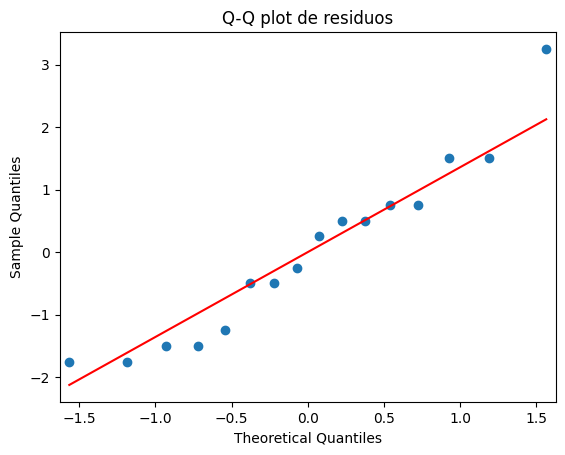

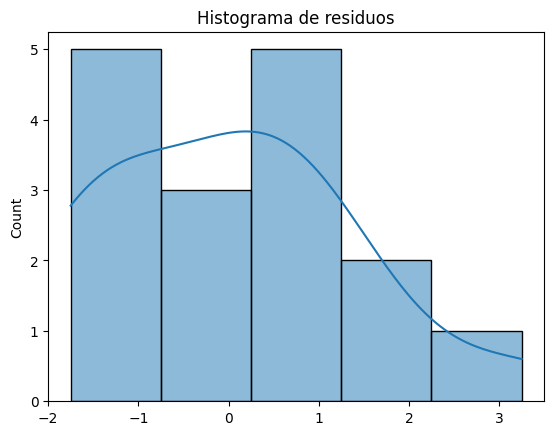

In [4]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()



In [5]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['metodo'] == 'A']['minutos']
grupo_B = df[df['metodo'] == 'B']['minutos']
grupo_C = df[df['metodo'] == 'C']['minutos']
grupo_D = df[df['metodo'] == 'D']['minutos']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")


Estadístico de Levene: 0.9474
p-valor: 0.4485


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     1.25 0.6805 -2.0416 4.5416  False
     A      C      5.5 0.0016  2.2084 8.7916   True
     A      D     3.25 0.0533 -0.0416 6.5416  False
     B      C     4.25  0.011  0.9584 7.5416   True
     B      D      2.0 0.3181 -1.2916 5.2916  False
     C      D    -2.25 0.2309 -5.5416 1.0416  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

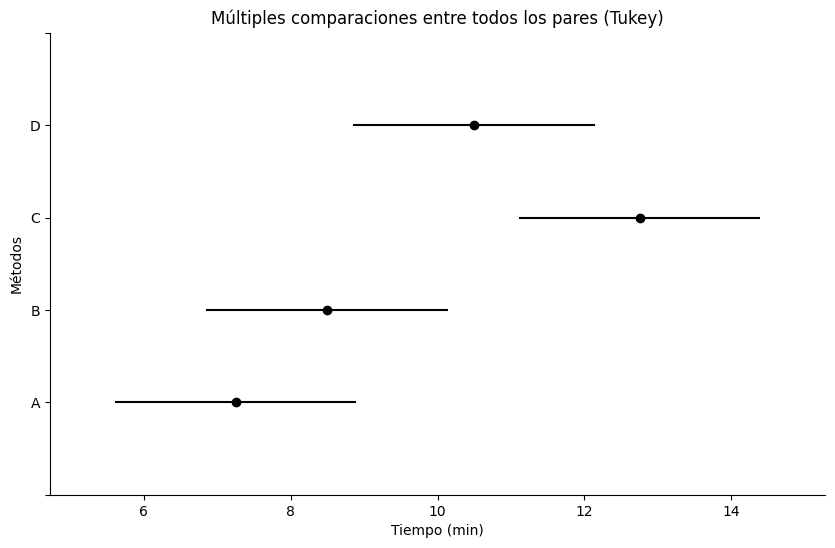

In [6]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['minutos'], # Variable de respuesta
    groups=df['metodo'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Métodos", xlabel="Tiempo (min)")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


In [7]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Calcular promedios de cada método

df.groupby(["metodo"]).mean()["minutos"]

,minutos
metodo,
A,7.25
B,8.50
C,12.75
D,10.50


In [8]:
#FRIDA SARAHI VAZQUEZ RUIZ
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(metodo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.702


In [9]:
#FRIDA SARAHI VAZQUEZ RUIZ
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["metodo"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.7020
f de Cohen = 1.5349
Potencia de la prueba = 0.9956


Conclusión. El diseño experimental es un DCA que cumple con los supuestos de normalidad y homoscedasticidad. Según el test de ANOVA hay diferencia significativa en al menos un método.
Haciendo el test de Tukey se encuentra que el método C es el único que muestra una diferencia significativa respecto a los demás. Sin embargo el método C aumenta el tiempo de ensamble, por lo que recomendamos evitarlo y usar en cambio el método A, B o D. Aunque el método A mostró mejores resultados en este experimento, no se encontró una diferencia significativa con los métodos B o D.
El tamaño del efecto es de 0.702, lo que indica que el cambio en los metodos de ensamble justifica

2. **Comparación de cuatro tipos de cuero:** Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva; la suela de éstos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independientes de las demás. Los datos (en miligramos) sobre el desgaste de cada tipo de cuero se muestran en la tabla.

| Tipo de cuero | Observaciones                  | Promedio |
|---------------|--------------------------------|----------|
| A             | 264, 260, 258, 241, 262, 255 | 256.7    |
| B             | 208, 220, 216, 200, 213, 206 | 209.8    |
| C             | 220, 263, 219, 225, 230, 228 | 230.8    |
| D             | 217, 226, 215, 227, 220, 222 | 220.7    |


In [10]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
cuero,observaciones}
A, 264
B, 208
C, 220
D, 217
A, 260
B, 220
C, 263
D, 226
A, 258
B, 216
C, 219
D, 215
A, 241
B, 200
C, 225
D, 227
A, 262
B, 213
C, 230
D, 220
A, 255
B, 206
C, 228
D, 222

'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,cuero,observaciones}
0,A,264
1,B,208
2,C,220
3,D,217
4,A,260
5,B,220
6,C,263
7,D,226
8,A,258
9,B,216


In [11]:
#FRIDA SARAHI VAZQUEZ RUIZ
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente


df = df.rename(columns={'observaciones}': 'observaciones'})

modelo = ols('observaciones ~ C(cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(cuero),7019.4583,3.0,22.7554,0.0
Residual,2056.5000,20.0,NaN,NaN


In [12]:
residuales = modelo.resid

valor-p (Shapiro) = 0.009670145138301391


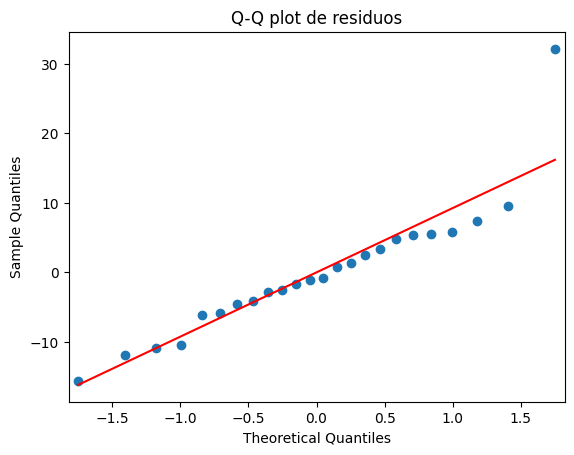

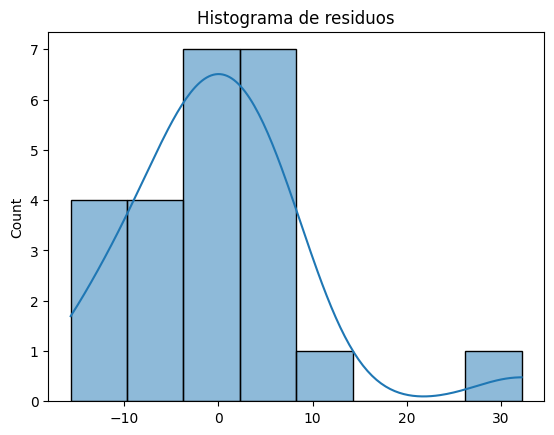

In [13]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()



In [14]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['cuero'] == 'A']['observaciones']
grupo_B = df[df['cuero'] == 'B']['observaciones']
grupo_C = df[df['cuero'] == 'C']['observaciones']
grupo_D = df[df['cuero'] == 'D']['observaciones']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")


Estadístico de Levene: 0.5797
p-valor: 0.6351


Lambda óptimo: -3.707788382033557


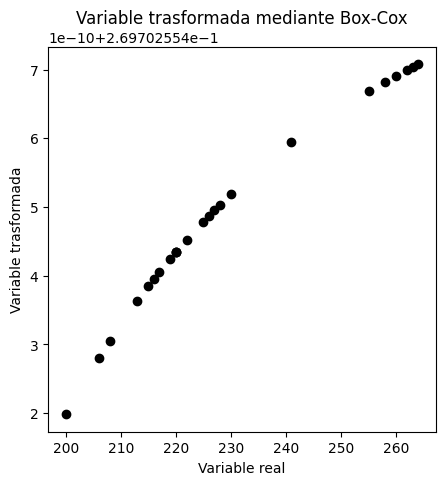

In [15]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["observaciones_boxcox"], lambda_opt = boxcox(df["observaciones"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["observaciones"], df["observaciones_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [16]:
#FRIDA SARAHI VAZQUEZ RUIZ
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente


df = df.rename(columns={'observaciones}': 'observaciones'})

modelo = ols('observaciones_boxcox ~ C(cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(cuero),0.0,3.0,23.3682,0.0
Residual,0.0,20.0,NaN,NaN


In [17]:
residuales = modelo.resid

valor-p (Shapiro) = 0.4576969192784245


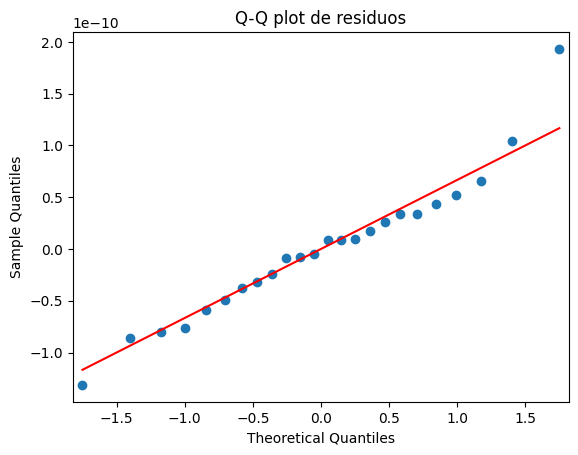

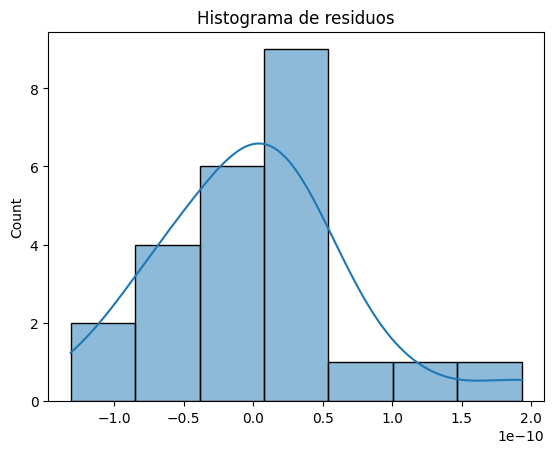

In [18]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()



In [19]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['cuero'] == 'A']['observaciones_boxcox']
grupo_B = df[df['cuero'] == 'B']['observaciones_boxcox']
grupo_C = df[df['cuero'] == 'C']['observaciones_boxcox']
grupo_D = df[df['cuero'] == 'D']['observaciones_boxcox']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")


Estadístico de Levene: 1.1788
p-valor: 0.3428


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower upper reject
------------------------------------------------
     A      B     -0.0    0.0  -0.0  -0.0   True
     A      C     -0.0 0.0048  -0.0  -0.0   True
     A      D     -0.0 0.0001  -0.0  -0.0   True
     B      C      0.0 0.0018   0.0   0.0   True
     B      D      0.0 0.0613  -0.0   0.0  False
     C      D     -0.0  0.401  -0.0   0.0  False
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

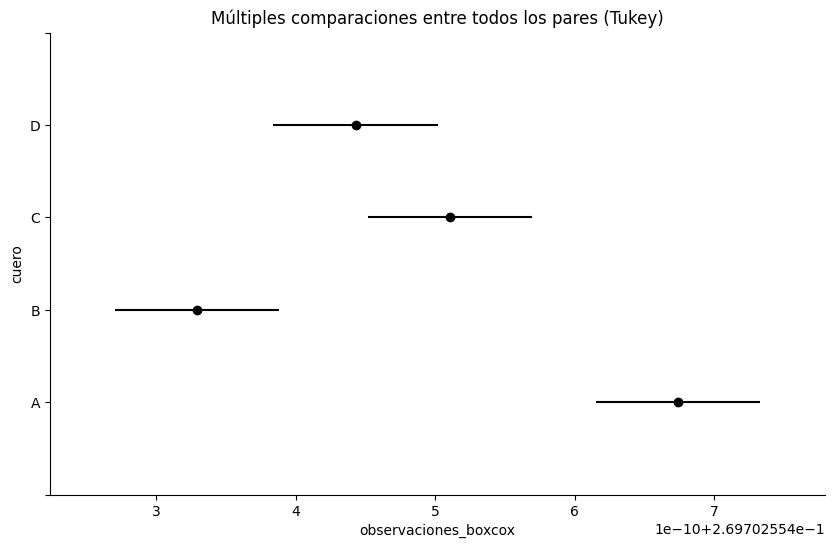

In [20]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['observaciones_boxcox'], # Variable de respuesta
    groups=df['cuero'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="cuero", xlabel="observaciones_boxcox")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


Conclusión: Tenemos como primera observación que en el test de shapiro no se cumple con la normalidad ya que nuestro valor-p fue de 0.0096 que es menor que 0.05, mientras que en nuestro test de levene si se cumple ya que si es mayor el p-valor, dado estos resultados realizamos nuestro ajuste con boxcox para asi poder cumplir con la normalidad y homocedasticidad. En nuestra prueba de Tukey como resultado tenemos que el cuero A es el de menos resistencia por lo que es mejor descartar este cuero, y se recomienda usar el cuero B o D ya que son con los que hay menos pérdida en su peso.


3. En un centro de investigación se realiza un estudio para comparar varios tratamientos que, al aplicarse previamente a los frijoles crudos, reducen su tiempo de cocción. Estos tratamientos son a base de bicarbonato de sodio y cloruro de sodio o sal común. El primer tratamiento ($T_1$) es el de control, que consiste en no aplicar ningún tratamiento. El tratamiento $T_2$ es el remojo en agua con bicarbonato de sodio, el $T_3$ es remojar en agua con sal común y el $T_4$ es remojar en agua con una combinación de ambos ingredientes en proporciones iguales. La variable de respuesta es el tiempo de cocción en minutos. Los datos se muestran en la siguiente tabla:

| $T_1$ | $T_2$  | $T_3$  | $T_4$  |
|---------|-----|-----|-----|
| 213     | 76  | 57  | 84  |
| 214     | 85  | 67  | 82  |
| 204     | 74  | 55  | 85  |
| 208     | 78  | 64  | 92  |
| 212     | 82  | 61  | 87  |
| 200     | 75  | 63  | 79  |
| 207     | 82  | 63  | 90  |



In [21]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
tratamiento,tiempo
T1,213
T2,76
T3,57
T4,84
T1,214
T2,85
T3,67
T4,82
T1,204
T2,74
T3,55
T4,85
T1,208
T2,78
T3,64
T4,92
T1,212
T2,82
T3,61
T4,87
T1,200
T2,75
T3,63
T4,79
T1,207
T2,82
T3,63
T4,90
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,tratamiento,tiempo
0,T1,213
1,T2,76
2,T3,57
3,T4,84
4,T1,214
5,T2,85
6,T3,67
7,T4,82
8,T1,204
9,T2,74


In [22]:
# ANOVA
#FRIDA SARAHI VAZQUEZ RUIZ
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('tiempo ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),95041.2500,3.0,1558.966,0.0
Residual,487.7143,24.0,NaN,NaN


In [23]:
residuales = modelo.resid

valor-p (Shapiro) = 0.34689165649615683


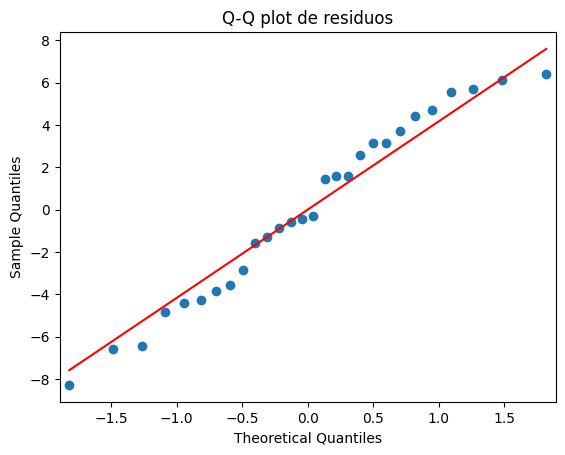

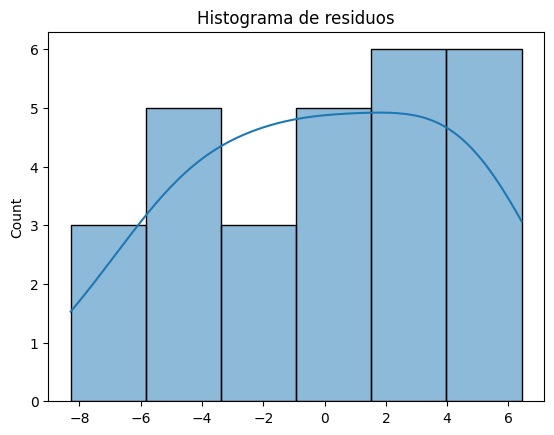

In [24]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [25]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tratamiento'] == 'T1']['tiempo']
grupo_B = df[df['tratamiento'] == 'T2']['tiempo']
grupo_C = df[df['tratamiento'] == 'T3']['tiempo']
grupo_D = df[df['tratamiento'] == 'T4']['tiempo']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1631
p-valor: 0.9201


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
    T1     T2 -129.4286    0.0 -136.0757 -122.7815   True
    T1     T3 -146.8571    0.0 -153.5043   -140.21   True
    T1     T4 -122.7143    0.0 -129.3614 -116.0672   True
    T2     T3  -17.4286    0.0  -24.0757  -10.7815   True
    T2     T4    6.7143 0.0471    0.0672   13.3614   True
    T3     T4   24.1429    0.0   17.4957     30.79   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

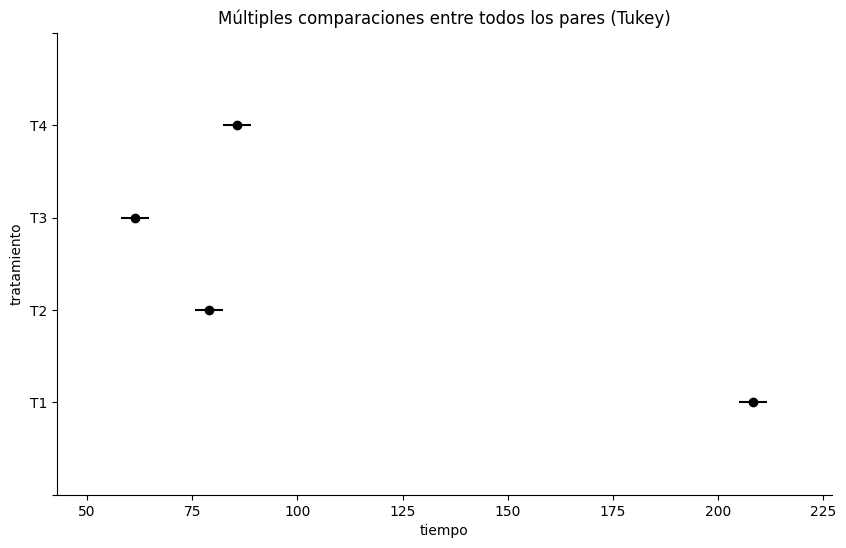

In [26]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['tiempo'], # Variable de respuesta
    groups=df['tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tratamiento", xlabel="tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [27]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Calcular promedios de cada método

df.groupby(["tratamiento"]).mean()["tiempo"]

,tiempo
tratamiento,
T1,208.285714
T2,78.857143
T3,61.428571
T4,85.571429


In [28]:
#FRIDA SARAHI VAZQUEZ RUIZ
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.995


In [29]:
#FRIDA SARAHI VAZQUEZ RUIZ
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["tratamiento"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9949
f de Cohen = 13.9596
Potencia de la prueba = 1.0000


Conclusión: Tenemos que nuestros supuestos de normalidad y homocedasticidad se cumplen en ambas nuestra hipotesis nula, en nuestro ANOVA tenemos que PR(>F)=0.0 este resultado es menos a 0.05 quiere decir que si existe una diferencia en los tiempos de cocción. En nuestra prueba de Tukey nos dio resultados diferentes en el tiempo segun su tratamiento, siendo que el mejor es el T3 ya que su tiempo de cocción es el mas optimo de usar, superando a los otros.

4. Para estudiar la confiabilidad de ciertos tableros electrónicos para carros, se someten a un envejecimiento acelerado durante 100 horas a determinada temperatura, y como variable de interés se mide la intensidad de corriente que circula entre dos puntos, cuyos valores aumentan con el deterioro. Se probaron 20 módulos repartidos de manera equitativa en cinco temperaturas y los resultados obtenidos fueron los siguientes:

| 20°C | 40°C | 60°C | 80°C | 100°C |
|------|------|------|------|-------|
| 15   | 17   | 23   | 28   | 45    |
| 18   | 21   | 19   | 32   | 51    |
| 13   | 11   | 25   | 34   | 57    |
| 12   | 16   | 22   | 31   | 48    |


In [30]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
temperatura,modulos
20°C,15
40°C,17
60°C,23
80°C,28
100°C,45
20°C,18
40°C,21
60°C,19
80°C,32
100°C,51
20°C,13
40°C,11
60°C,25
80°C,34
100°C,57
20°C,12
40°C,16
60°C,22
80°C,31
100°C,48
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,temperatura,modulos
0,20°C,15
1,40°C,17
2,60°C,23
3,80°C,28
4,100°C,45
5,20°C,18
6,40°C,21
7,60°C,19
8,80°C,32
9,100°C,51


In [31]:
#FRIDA SARAHI VAZQUEZ RUIZ
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('modulos ~ C(temperatura)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(temperatura),3411.8,4.0,68.0545,0.0
Residual,188.0,15.0,NaN,NaN


In [32]:
residuales = modelo.resid

valor-p (Shapiro) = 0.7785351257478303


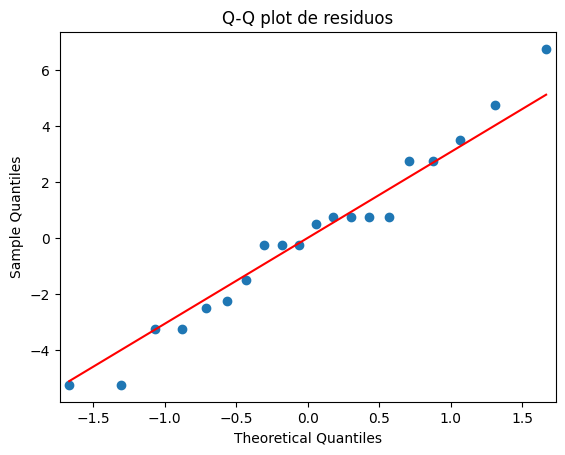

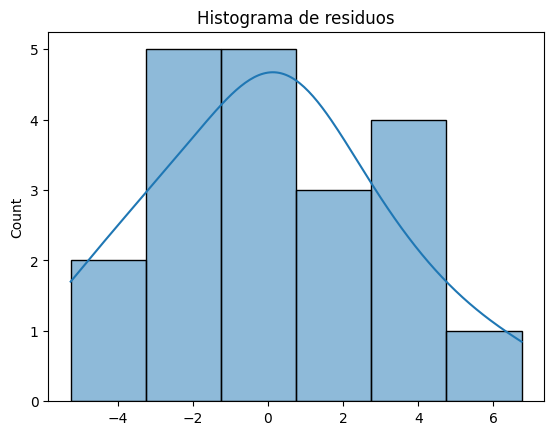

In [33]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [34]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

grupo_20C = df[df['temperatura'] == '20°C']['modulos']
grupo_40C = df[df['temperatura'] == '40°C']['modulos']
grupo_60C = df[df['temperatura'] == '60°C']['modulos']
grupo_80C = df[df['temperatura'] == '80°C']['modulos']
grupo_100C = df[df['temperatura'] == '100°C']['modulos']

stat, p = levene(grupo_20C, grupo_40C, grupo_60C, grupo_80C, grupo_100C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.6808
p-valor: 0.6160


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
 100°C   20°C   -35.75    0.0 -43.4801 -28.0199   True
 100°C   40°C    -34.0    0.0 -41.7301 -26.2699   True
 100°C   60°C    -28.0    0.0 -35.7301 -20.2699   True
 100°C   80°C    -19.0    0.0 -26.7301 -11.2699   True
  20°C   40°C     1.75 0.9535  -5.9801   9.4801  False
  20°C   60°C     7.75 0.0493   0.0199  15.4801   True
  20°C   80°C    16.75 0.0001   9.0199  24.4801   True
  40°C   60°C      6.0 0.1696  -1.7301  13.7301  False
  40°C   80°C     15.0 0.0002   7.2699  22.7301   True
  60°C   80°C      9.0 0.0191   1.2699  16.7301   True
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

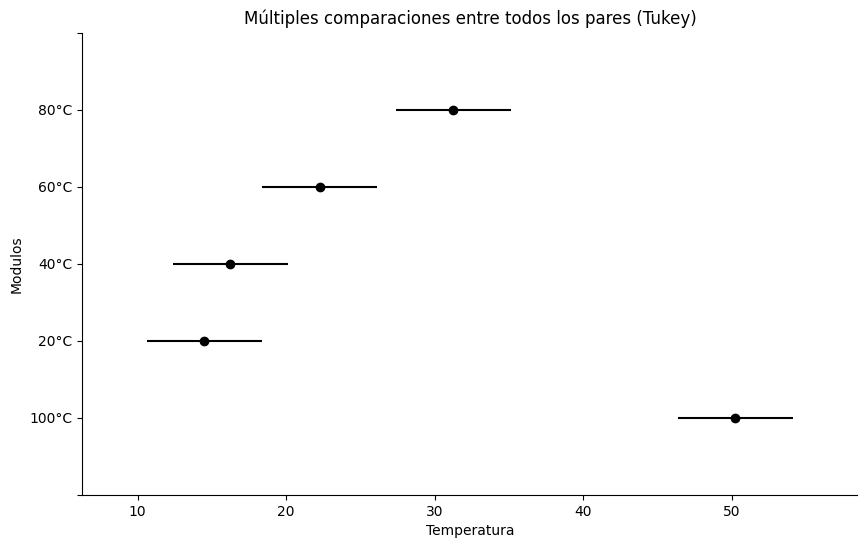

In [35]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['modulos'], # Variable de respuesta
    groups=df['temperatura'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Modulos", xlabel="Temperatura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [36]:
# Calcular promedios de cada método

df.groupby(["temperatura"]).mean()["modulos"]

,modulos
temperatura,
100°C,50.25
20°C,14.50
40°C,16.25
60°C,22.25
80°C,31.25


In [37]:
#FRIDA SARAHI VAZQUEZ RUIZ
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(temperatura)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.948


In [38]:
#FRIDA SARAHI VAZQUEZ RUIZ
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["temperatura"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9478
f de Cohen = 4.2600
Potencia de la prueba = 1.0000


Conclusion: Podemos observar que se cumple el test de shapiro y levene, mostrando que existe normalidad y homocedasticidad, en nuestra prueba de Tukey podemos observar que las temperaturas mas bajas las cuales son 20°C y 40°C no existen una diferencia grande entre ellas, como resultado podemos decir que es mejor trabajar con temperaturas menores a 40°C, ya que en 60°C sufren un descontrol al elevarse la temperatura y se intensifica la corriente

5. En una empresa de manufactura se propone un tratamiento para reducir el porcentaje de productos defectuosos. Para validar esta propuesta se diseñó un experimento en el que se producía con o sin la propuesta de mejora. Cada corrida experimental consistió en producir un lote y la variable de respuesta es el porcentaje de producto defectuoso. Se hicieron 25 réplicas para cada tratamiento. Los datos obtenidos se muestran a continuación:

| Tratamiento     | Porcentaje de producto defectuoso                                     |
|-----------------|----------------------------------------------------------------------|
| Con tratam.     | 5.3, 4.0, 4.0, 4.0, 2.6, 2.1, 5.1, 4.1, 4.1, 3.2, 5.1, 2.2, 4.1     |
| Sin tratam.     | 8.0, 13.2, 7.2, 8.2, 9.1, 6.7, 12.6, 16.3, 9.2, 6.4, 7.2, 17.2, 12.3 |


In [39]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
tratamiento,porcentaje_defectuoso
1con_tratam,5.3
1con_tratam,4.0
1con_tratam,4.0
1con_tratam,4.0
1con_tratam,2.6
1con_tratam,2.1
1con_tratam,5.1
1con_tratam,4.1
1con_tratam,4.1
1con_tratam,3.2
1con_tratam,5.1
1con_tratam,2.2
1con_tratam,4.1
2sin_tratam,8.0
2sin_tratam,13.2
2sin_tratam,7.2
2sin_tratam,8.2
2sin_tratam,9.1
2sin_tratam,6.7
2sin_tratam,12.6
2sin_tratam,16.3
2sin_tratam,9.2
2sin_tratam,6.4
2sin_tratam,7.2
2sin_tratam,17.2
2sin_tratam,12.3
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,tratamiento,porcentaje_defectuoso
0,1con_tratam,5.3
1,1con_tratam,4.0
2,1con_tratam,4.0
3,1con_tratam,4.0
4,1con_tratam,2.6
5,1con_tratam,2.1
6,1con_tratam,5.1
7,1con_tratam,4.1
8,1con_tratam,4.1
9,1con_tratam,3.2


In [40]:
#FRIDA SARAHI VAZQUEZ RUIZ
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('porcentaje_defectuoso ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),269.4496,1.0,37.1028,0.0
Residual,174.2938,24.0,NaN,NaN


In [41]:
residuales = modelo.resid

valor-p (Shapiro) = 0.08240142335256262


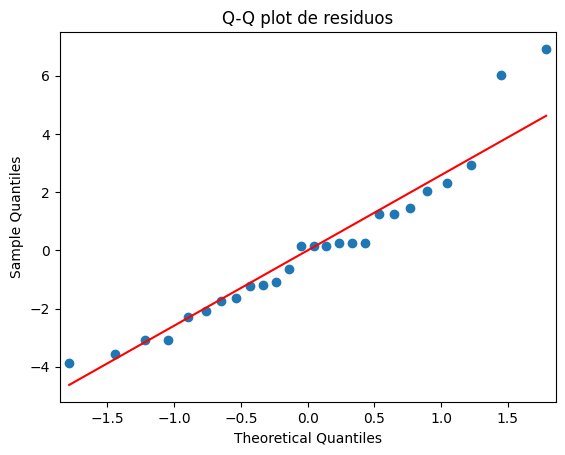

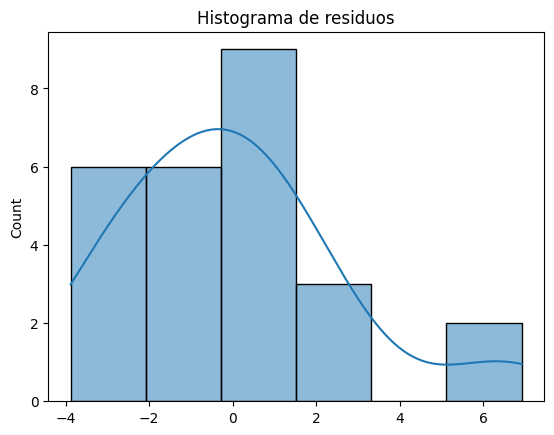

In [42]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [43]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_1con_tratam = df[df['tratamiento'] == '1con_tratam']['porcentaje_defectuoso']
grupo_2sin_tratam = df[df['tratamiento'] == '2sin_tratam']['porcentaje_defectuoso']

stat, p = levene(grupo_1con_tratam, grupo_2sin_tratam)
print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")


Estadístico de Levene: 8.7144
p-valor: 0.0070


Lambda óptimo: -0.05387226813423122


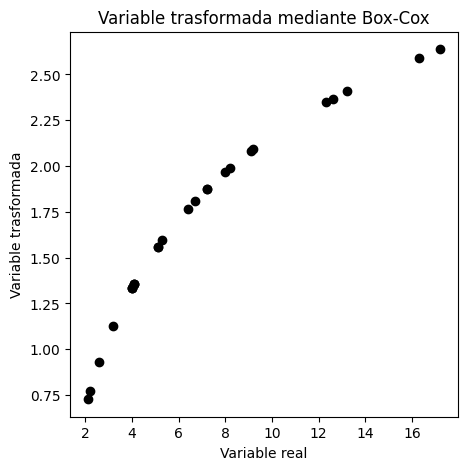

In [44]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["porcentaje_defectuoso_boxcox"], lambda_opt = boxcox(df["porcentaje_defectuoso"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["porcentaje_defectuoso"], df["porcentaje_defectuoso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [45]:
#FRIDA SARAHI VAZQUEZ RUIZ
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente


df = df.rename(columns={'porcentaje_defectuoso}': 'porcentaje_defectuoso'})

modelo = ols('porcentaje_defectuoso_boxcox ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),5.0403,1.0,58.8438,0.0
Residual,2.0557,24.0,NaN,NaN


In [46]:
residuales = modelo.resid

valor-p (Shapiro) = 0.5855089546322916


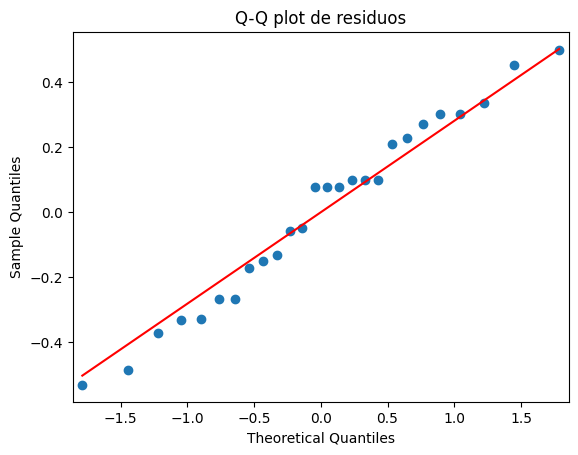

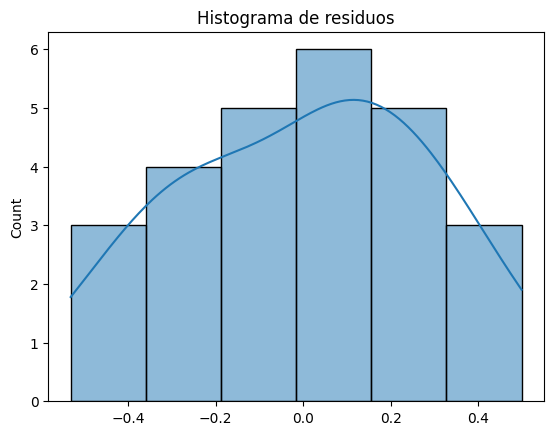

In [47]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()



In [48]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]

grupo_1con_tratam = df[df['tratamiento'] == '1con_tratam']['porcentaje_defectuoso_boxcox']
grupo_2sin_tratam = df[df['tratamiento'] == '2sin_tratam']['porcentaje_defectuoso_boxcox']

stat, p = levene(grupo_1con_tratam, grupo_2sin_tratam)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")


Estadístico de Levene: 0.3797
p-valor: 0.5436


    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1      group2   meandiff p-adj lower  upper  reject
-----------------------------------------------------------
1con_tratam 2sin_tratam   0.8806   0.0 0.6437 1.1175   True
-----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

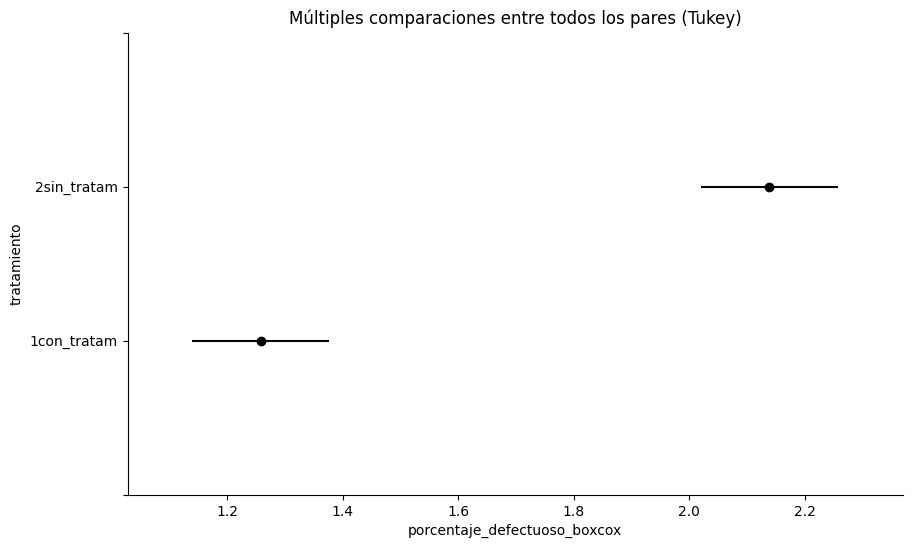

In [49]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['porcentaje_defectuoso_boxcox'], # Variable de respuesta
    groups=df['tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tratamiento", xlabel="porcentaje_defectuoso_boxcox")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


Conclusion: En este problema podemos observar que no se cumple el supuesto de homocedasticidad, el de normalidad si, pero como no se cumplen los dos tenemos que hacer boxcox, despues analizamos la prueba de tukey donde en la grafica nos muestra una gran diferencia entre los dos tratamientos, pero podemos recomendar mas que si contengan tratamiento (1con_tratam) ya que nos genera mayor efectividad,

6. Una compañía farmacéutica desea evaluar el efecto que tiene la cantidad de almidón en la dureza de las tabletas. Se decidió producir lotes con una cantidad determinada de almidón, y que las cantidades de almidón a aprobar fueran 2%, 5% y 10%. La variable de respuesta sería el promedio de la dureza de 20 tabletas de cada lote. Se hicieron 4 réplicas por tratamiento y se obtuvieron los siguientes resultados:

| % de almidón | Dureza               |
|--------------|----------------------|
| 2            | 4.3, 5.2, 4.8, 4.5  |
| 5            | 6.5, 7.3, 6.9, 6.1  |
| 10           | 9.0, 7.8, 8.5, 8.1  |


In [50]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
almidon,dureza
P2,4.3
P5,6.5
P10,9.0
P2,5.2
P5,7.3
P10,7.8
P2,4.8
P5,6.9
P10,8.5
P2,4.5
P5,6.1
P10,8.1
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,almidon,dureza
0,P2,4.3
1,P5,6.5
2,P10,9.0
3,P2,5.2
4,P5,7.3
5,P10,7.8
6,P2,4.8
7,P5,6.9
8,P10,8.5
9,P2,4.5


In [51]:
#FRIDA SARAHI VAZQUEZ RUIZ
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('dureza ~ C(almidon)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(almidon),26.7267,2.0,58.1014,0.0
Residual,2.0700,9.0,NaN,NaN


In [52]:
residuales = modelo.resid

valor-p (Shapiro) = 0.42952068080370853


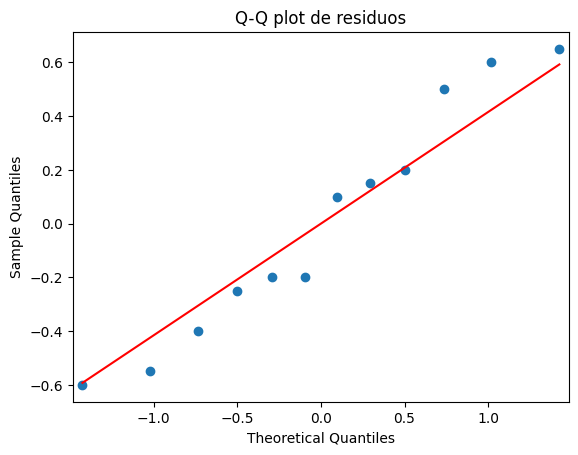

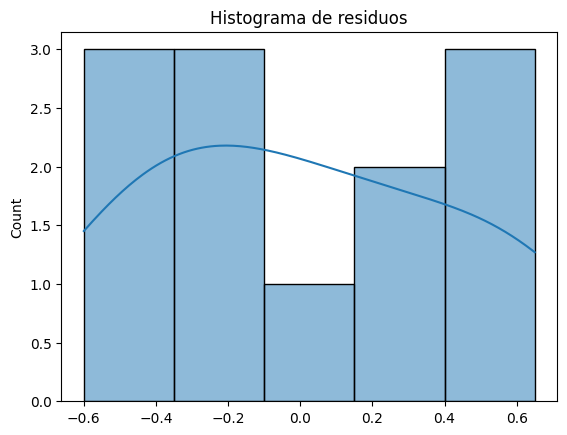

In [53]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [54]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_2A = df[df['almidon'] == 'P2']['dureza']
grupo_5B= df[df['almidon'] == 'P5']['dureza']
grupo_10C = df[df['almidon'] == 'P10']['dureza']


stat, p = levene(grupo_2A, grupo_5B, grupo_10C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2667
p-valor: 0.7718


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   P10     P2    -3.65    0.0 -4.5968 -2.7032   True
   P10     P5    -1.65 0.0023 -2.5968 -0.7032   True
    P2     P5      2.0 0.0006  1.0532  2.9468   True
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

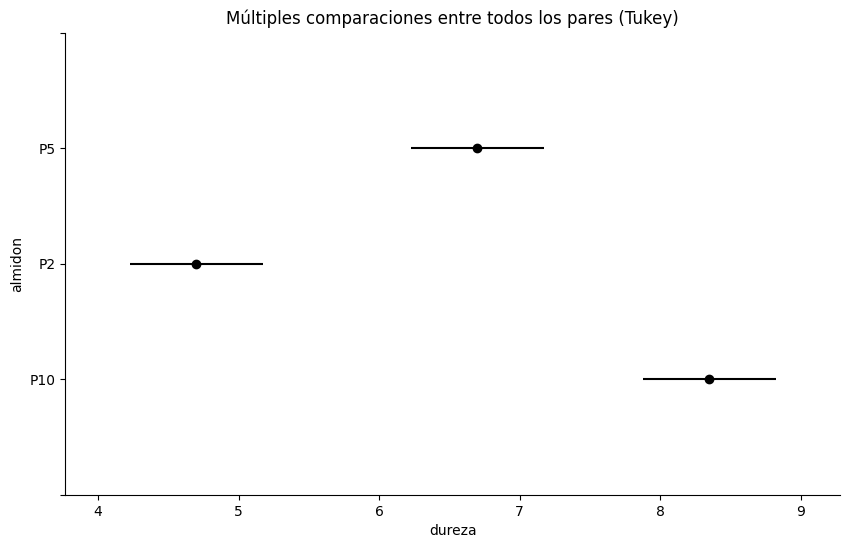

In [55]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['dureza'], # Variable de respuesta
    groups=df['almidon'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="almidon", xlabel="dureza")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [56]:
#FRIDA SARAHI VAZQUEZ RUIZ
df.groupby(["almidon"]).mean()["dureza"]

,dureza
almidon,
P10,8.35
P2,4.70
P5,6.70


In [57]:
#FRIDA SARAHI VAZQUEZ RUIZ
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(almidon)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.928


In [58]:
#FRIDA SARAHI VAZQUEZ RUIZ
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["almidon"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9281
f de Cohen = 3.5932
Potencia de la prueba = 1.0000


Conclusión: En ambas pruebas se acepta tanto la normalidad como la homocedasticidad, y basandonos en la prueba de tukey que si existe diferencia entre estas y son independientes cada una, segun sea el porcentaje de almidon es como se obtiene la dureza de menor a mayor, podemos decir que se recomienda utilizar el almidon segun sea las necesidades de dureza que querramos obtener.

7. Los datos que se presentan enseguida son rendimientos en toneladas por hectárea de un pasto con tres niveles de fertilización nitrogenada. El diseño fue completamente aleatorizado, con cinco repeticiones por tratamiento.

| Niveles de nitrógeno | Rendimientos (ton/ha)       |
|-----------------------|----------------------------|
| 1                     | 14.823, 14.676, 14.720, 14.5141, 15.065 |
| 2                     | 25.151, 25.401, 25.131, 25.031, 25.267 |
| 3                     | 32.605, 32.460, 32.256, 32.669, 32.111 |


In [59]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
nitrogeno,rendimiento
N1,14.823
N2,25.151
N3,32.605
N1,14.676
N2,25.401
N3,32.460
N1,14.720
N2,25.131
N3,32.256
N1,14.5141
N2,25.031
N3,32.669
N1,15.065
N2,25.267
N3,32.111
'''

df = pd.read_csv(StringIO(datos))
df

,nitrogeno,rendimiento
0,N1,14.8230
1,N2,25.1510
2,N3,32.6050
3,N1,14.6760
4,N2,25.4010
5,N3,32.4600
6,N1,14.7200
7,N2,25.1310
8,N3,32.2560
9,N1,14.5141


In [60]:
#FRIDA SARAHI VAZQUEZ RUIZ
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('rendimiento ~ C(nitrogeno)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(nitrogeno),788.3408,2.0,10131.6193,0.0
Residual,0.4669,12.0,NaN,NaN


In [61]:
residuales = modelo.resid

valor-p (Shapiro) = 0.8890610190283594


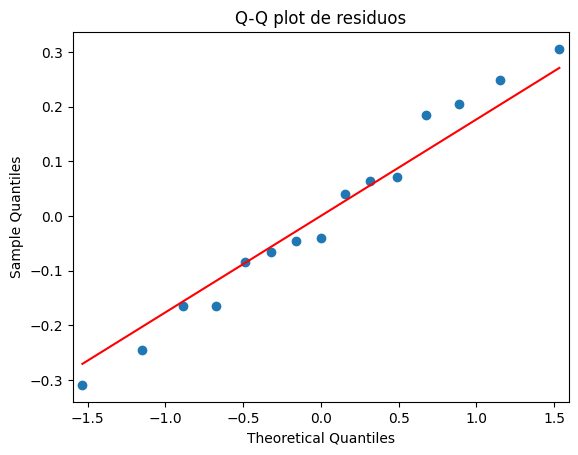

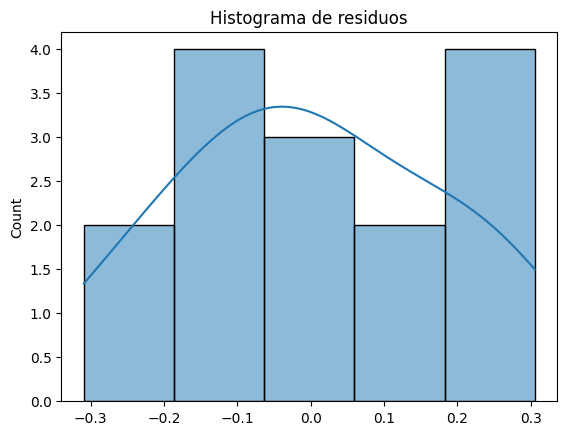

In [62]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [63]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_N1 = df[df['nitrogeno'] == 'N1']['rendimiento']
grupo_N2 = df[df['nitrogeno'] == 'N2']['rendimiento']
grupo_N3 = df[df['nitrogeno'] == 'N3']['rendimiento']

stat, p = levene(grupo_N1, grupo_N2, grupo_N3,)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5372
p-valor: 0.5978


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    N1     N2  10.4366   0.0 10.1038 10.7694   True
    N1     N3  17.6606   0.0 17.3278 17.9934   True
    N2     N3    7.224   0.0  6.8912  7.5568   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

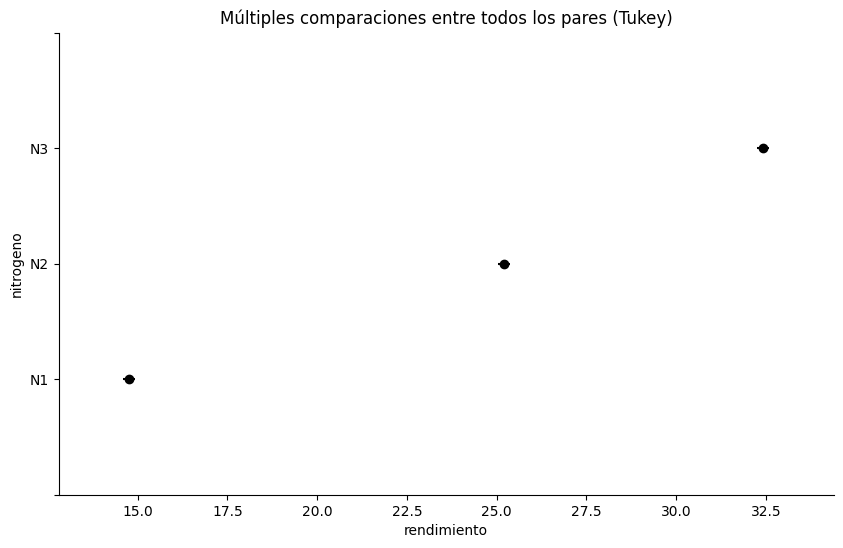

In [64]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['rendimiento'], # Variable de respuesta
    groups=df['nitrogeno'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="nitrogeno", xlabel="rendimiento")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [65]:
df.groupby(["nitrogeno"]).mean()["rendimiento"]

,rendimiento
nitrogeno,
N1,14.75962
N2,25.19620
N3,32.42020


In [66]:
#FRIDA SARAHI VAZQUEZ RUIZ
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(nitrogeno)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.999


In [67]:
#FRIDA SARAHI VAZQUEZ RUIZ
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["nitrogeno"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9994
f de Cohen = 41.0926
Potencia de la prueba = 1.0000


Conclusión: Aqui se evaluo el impacto de los 3 niveles de fertilización, se acepta la normalidad y la homocedaticidad, en nuestro ANOVA se rechaza la hipotesis nula por nuestro valor PR(>F) que es menor a 0.05. En nuestra prueba de Tukey podemos ver que hacienden de manera escalonada, por esto se recomienda utilzar el nivel 3 nitrogeno ya que este maximiza el rendimeinto y por ende mejores resultados.

8. Un químico del departamento de desarrollo de un laboratorio farmacéutico desea conocer cómo influye el tipo de aglutinante utilizado en tabletas de ampicilina de 500 mg en el porcentaje de friabilidad; para ello, se eligen los siguientes aglutinantes: polivinilpirrolidona (PVP), carboximetilcelulosa sódica (CMC) y grenetina (Gre). Los resultados del diseño experimental son los siguientes:

| Aglutinante | % de friabilidad          |
|-------------|---------------------------|
| PVP         | 0.485, 0.250, 0.073, 0.205, 0.161 |
| CMC         | 9.64, 9.37, 9.53, 9.86, 9.79       |
| Gre         | 0.289, 0.275, 0.612, 0.152, 0.137  |


In [68]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
aglutinante,friabilidad
1pvp,0.485
2cmc,9.64
3gre,0.289
1pvp,0.250
2cmc,9.37
3gre,0.275
1pvp,0.073
2cmc,9.53
3gre,0.612
1pvp,0.205
2cmc,9.86
3gre,0.152
1pvp,0.161
2cmc,9.79
3gre,0.137
'''

df = pd.read_csv(StringIO(datos))
df

,aglutinante,friabilidad
0,1pvp,0.485
1,2cmc,9.640
2,3gre,0.289
3,1pvp,0.250
4,2cmc,9.370
5,3gre,0.275
6,1pvp,0.073
7,2cmc,9.530
8,3gre,0.612
9,1pvp,0.205


In [69]:
#FRIDA SARAHI VAZQUEZ RUIZ
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('friabilidad ~ C(aglutinante)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(aglutinante),292.9210,2.0,4420.9726,0.0
Residual,0.3975,12.0,NaN,NaN


In [70]:
residuales = modelo.resid

valor-p (Shapiro) = 0.42143454193870405


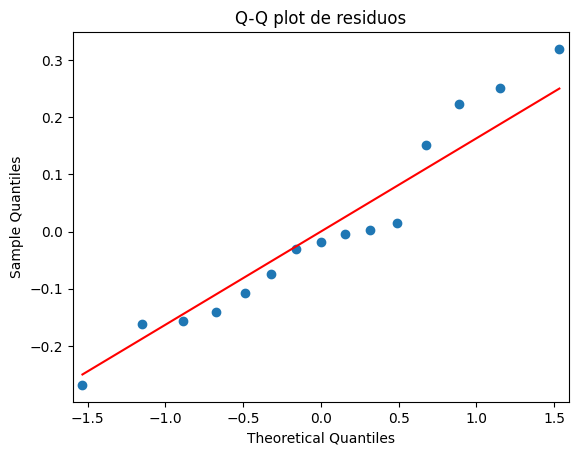

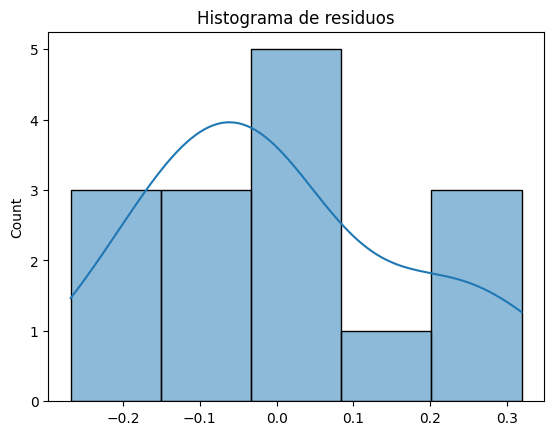

In [71]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [72]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_1pvp = df[df['aglutinante'] == '1pvp']['friabilidad']
grupo_2cmc = df[df['aglutinante'] == '2cmc']['friabilidad']
grupo_3gre = df[df['aglutinante'] == '3gre']['friabilidad']


stat, p = levene(grupo_1pvp, grupo_2cmc, grupo_3gre)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2250
p-valor: 0.8018


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  1pvp   2cmc   9.4032   0.0  9.0961  9.7103   True
  1pvp   3gre   0.0582  0.87 -0.2489  0.3653  False
  2cmc   3gre   -9.345   0.0 -9.6521 -9.0379   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

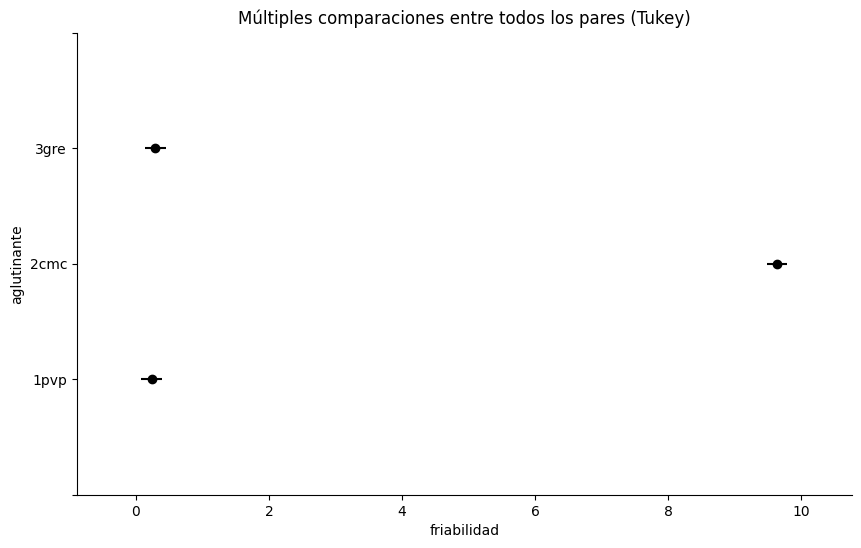

In [73]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['friabilidad'], # Variable de respuesta
    groups=df['aglutinante'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="aglutinante", xlabel="friabilidad")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [74]:
#FRIDA SARAHI VAZQUEZ RUIZ
df.groupby(["aglutinante"]).mean()["friabilidad"]

,friabilidad
aglutinante,
1pvp,0.2348
2cmc,9.6380
3gre,0.2930


In [75]:
#FRIDA SARAHI VAZQUEZ RUIZ
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(aglutinante)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.999


In [76]:
#FRIDA SARAHI VAZQUEZ RUIZ
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["aglutinante"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9986
f de Cohen = 27.1446
Potencia de la prueba = 1.0000


Conclusión: Se evalua el impacto de tres tipos de aglutinante, nuestra prueba de shapiro y levene aceptan la hipotesis nula, seguimos con la prueba de tukey podemos ver que el aglutinante 2cmc eleva demaciado la friabilidad por esto se recomienda descartar esta y tulizar mejor los otros dos ya sea pvc o gre, para garantizar una mejor calidad en nuestro producto.

9. Se cultivaron cuatro diferentes clonas de *agave tequilana* bajo un mismo esquema de manejo. Se quiere saber qué clona es la que responde mejor a dicho manejo, evaluando el nivel de respuesta con el porcentaje de azúcares reductores totales en base húmeda. Los datos se muestran a continuación:

| Clona | Porcentaje de azúcares reductores totales |
|-------|------------------------------------------|
| 1     | 8.69, 6.68, 6.83, 6.43, 10.30            |
| 2     | 8.00, 16.41, 12.43, 10.99, 15.53         |
| 3     | 17.39, 13.73, 15.62, 17.05, 15.42        |
| 4     | 10.37, 9.16, 8.83, 4.40, 10.38           |


In [77]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
clona,porcentaje_azucar
C1,8.69
C2,8.00
C3,17.39
C4,10.37
C1,6.68
C2,16.41
C3,13.73
C4,9.16
C1,6.83
C2,12.43
C3,15.62
C4,8.83
C1,6.43
C2,10.99
C3,17.05
C4,4.40
C1,10.30
C2,15.53
C3,15.42
C4,10.38
'''

df = pd.read_csv(StringIO(datos))
df

,clona,porcentaje_azucar
0,C1,8.69
1,C2,8.00
2,C3,17.39
3,C4,10.37
4,C1,6.68
5,C2,16.41
6,C3,13.73
7,C4,9.16
8,C1,6.83
9,C2,12.43


In [78]:
#FRIDA SARAHI VAZQUEZ RUIZ
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('porcentaje_azucar ~ C(clona)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(clona),209.9072,3.0,12.3271,0.0002
Residual,90.8168,16.0,NaN,NaN


In [79]:
residuales = modelo.resid

valor-p (Shapiro) = 0.7677173153296002


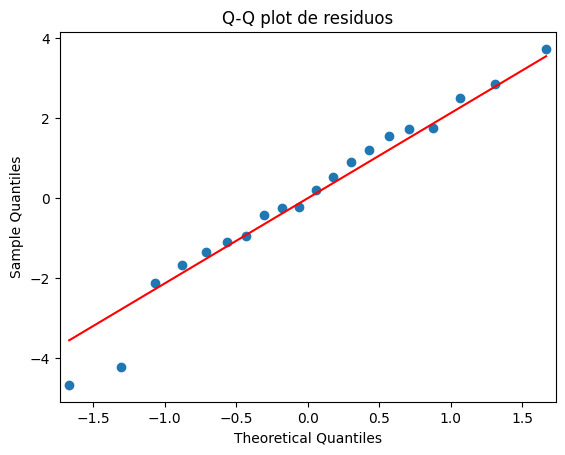

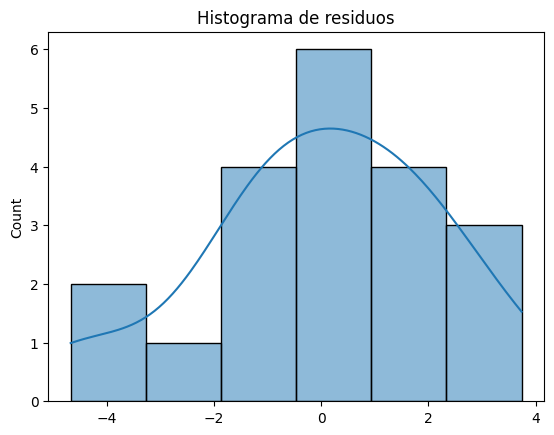

In [80]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [81]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_C1 = df[df['clona'] == 'C1']['porcentaje_azucar']
grupo_C2 = df[df['clona'] == 'C2']['porcentaje_azucar']
grupo_C3 = df[df['clona'] == 'C3']['porcentaje_azucar']
grupo_C4 = df[df['clona'] == 'C4']['porcentaje_azucar']


stat, p = levene(grupo_C1, grupo_C2, grupo_C3, grupo_C4)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9749
p-valor: 0.4290


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    C1     C2    4.886 0.0237   0.575  9.197   True
    C1     C3    8.056 0.0003   3.745 12.367   True
    C1     C4    0.842 0.9428  -3.469  5.153  False
    C2     C3     3.17 0.1939  -1.141  7.481  False
    C2     C4   -4.044 0.0699  -8.355  0.267  False
    C3     C4   -7.214  0.001 -11.525 -2.903   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

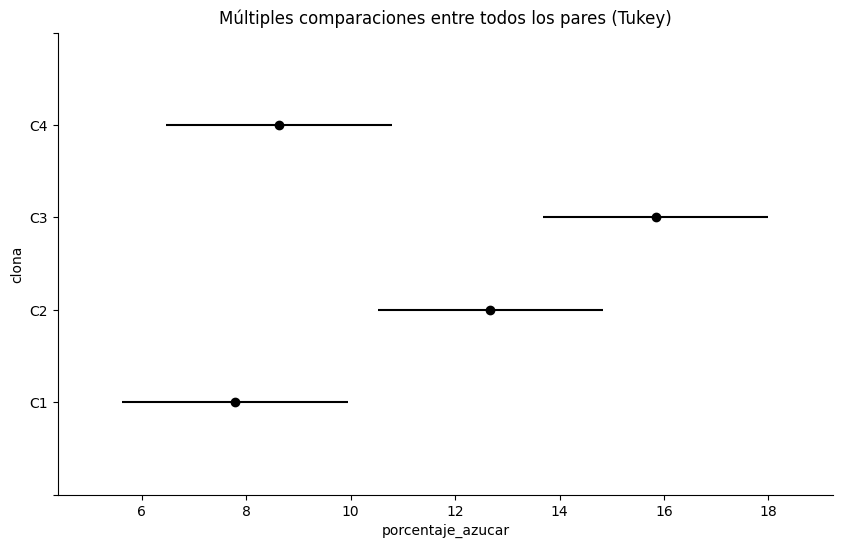

In [82]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['porcentaje_azucar'], # Variable de respuesta
    groups=df['clona'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="clona", xlabel="porcentaje_azucar")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [83]:
#FRIDA SARAHI VAZQUEZ RUIZ
df.groupby(["clona"]).mean()["porcentaje_azucar"]

,porcentaje_azucar
clona,
C1,7.786
C2,12.672
C3,15.842
C4,8.628


In [84]:
#FRIDA SARAHI VAZQUEZ RUIZ
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(clona)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.698


In [85]:
#FRIDA SARAHI VAZQUEZ RUIZ
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["clona"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.6980
f de Cohen = 1.5203
Potencia de la prueba = 0.9997


Conclusión: Aqui evaluaremos que clona es mejor, en nuestras primeras pruebas se aceptan, quiere decir que si existe normalidad y homocedasticidad.
En nuestra prueba de Tukey podemos analizar las 4 clonas y vemos que es mejor la 3 ya que nos da la mejor respuesta dando una eficiencia del 15.84% y se sugiere descartar las clonas 1 y 4 debido a su bajo rendimiento.

10. Uno de los defectos que causan mayor desperdicio en la manufactura de discos ópticos compactos son los llamados “cometas”. Típicamente, se trata de una partícula que opone resistencia al fluido en la etapa de entintado. Se quiere comprobar de manera experimental la efectividad de un tratamiento de limpieza de partículas que está basado en fuerza centrípeta y aire ionizado. A 12 lotes de 50 CD se les aplica el tratamiento y a otros 12 lotes no se les aplica; en cada caso se mide el porcentaje de discos que presentan cometas, los resultados son los siguientes:

| Con tratamiento      | Sin tratamiento      |
|----------------------|----------------------|
| 5.30   | 8.02  |
| 4.03   | 13.18 |
| 4.00   | 7.15  |
| 2.56   | 9.11  |
| 5.06   | 8.23  |
| 4.06   | 16.3  |
| 2.08   | 9.20  |
| 4.03   | 6.35  |
| 2.04   | 7.15  |
| 1.18   | 8.66  |


In [86]:
#FRIDA SARAHI VAZQUEZ RUIZ
import pandas as pd
from io import StringIO

datos = '''
tratamiento, porcentaje_discos
1c,5.30
1c,4.03
1c,4.00
1c,2.56
1c,5.06
1c,4.06
1c,2.08
1c,4.03
1c,2.04
1c,1.18
2s,8.02
2s,13.18
2s,7.15
2s,9.11
2s,8.23
2s,16.3
2s,9.20
2s,6.35
2s,7.15
2s,8.66
'''

df = pd.read_csv(StringIO(datos))
df

,tratamiento,porcentaje_discos
0,1c,5.30
1,1c,4.03
2,1c,4.00
3,1c,2.56
4,1c,5.06
5,1c,4.06
6,1c,2.08
7,1c,4.03
8,1c,2.04
9,1c,1.18


In [87]:
#FRIDA SARAHI VAZQUEZ RUIZ
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# Clean column names to remove any leading/trailing whitespace
df.columns = df.columns.str.strip()

# variable de respuesta ~ tratamiento
modelo = ols('porcentaje_discos ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),174.1090,1.0,30.6057,0.0
Residual,102.3981,18.0,NaN,NaN


In [88]:
residuales = modelo.resid

valor-p (Shapiro) = 0.013152795271816857


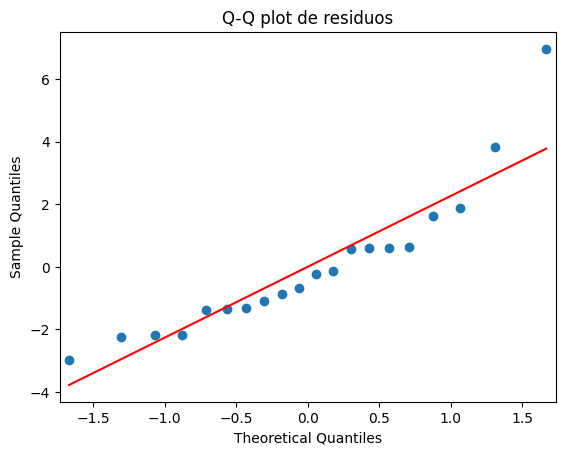

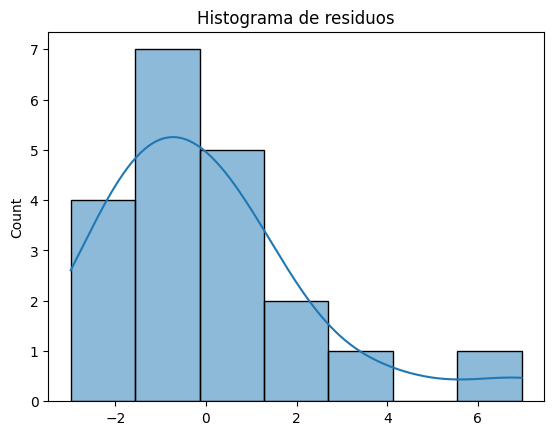

In [89]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [90]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_1c = df[df['tratamiento'] == '1c']['porcentaje_discos']
grupo_2s = df[df['tratamiento'] == '2s']['porcentaje_discos']


stat, p = levene(grupo_1c, grupo_2s)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1180
p-valor: 0.3043


Lambda óptimo: 0.32061169162391906


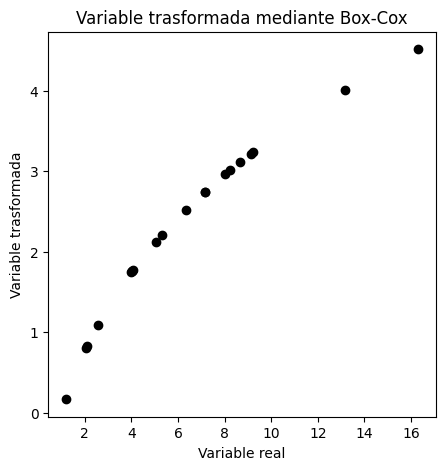

In [91]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["porcentaje_discos_boxcox"], lambda_opt = boxcox(df["porcentaje_discos"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["porcentaje_discos"], df["porcentaje_discos_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [92]:
#FRIDA SARAHI VAZQUEZ RUIZ
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente


df = df.rename(columns={'porcentaje_discos}': 'porcentaje_discos'})

modelo = ols('porcentaje_discos_boxcox ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),15.8598,1.0,38.9108,0.0
Residual,7.3367,18.0,NaN,NaN


In [93]:
residuales = modelo.resid

valor-p (Shapiro) = 0.9455348310737177


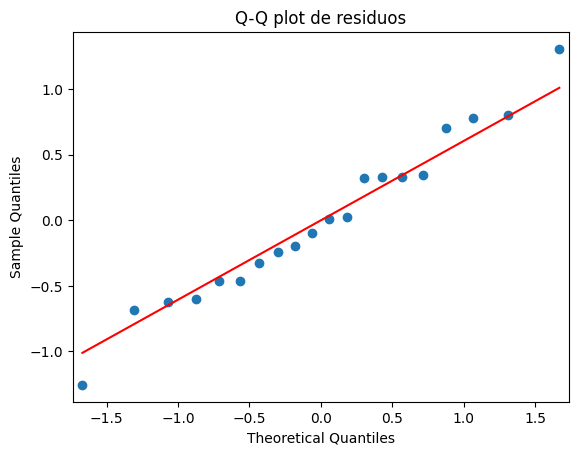

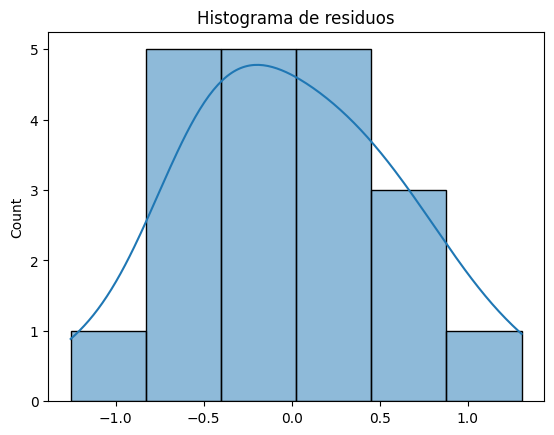

In [94]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()



In [95]:
#FRIDA SARAHI VAZQUEZ RUIZ
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]

grupo_1c = df[df['tratamiento'] == '1c']['porcentaje_discos_boxcox']
grupo_2s = df[df['tratamiento'] == '2s']['porcentaje_discos_boxcox']


stat, p = levene(grupo_1c, grupo_2s)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")


Estadístico de Levene: 0.1523
p-valor: 0.7009


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
    1c     2s    1.781   0.0 1.1812 2.3808   True
-------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

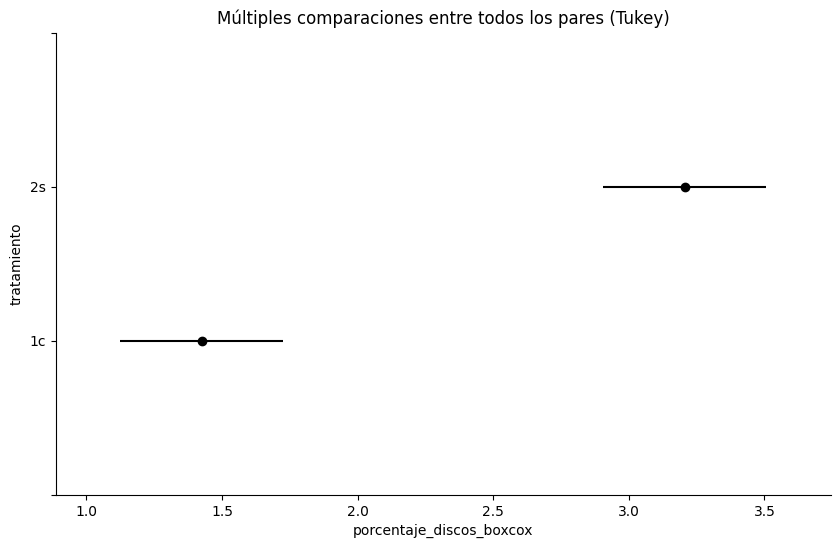

In [96]:
#FRIDA SARAHI VAZQUEZ RUIZ
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['porcentaje_discos_boxcox'], # Variable de respuesta
    groups=df['tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tratamiento", xlabel="porcentaje_discos_boxcox")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


Conclusión: Lo que queremos saber es si es recomendable usar el metodo de limpieza en el producto, en nuestros dos test la normalidad no se acepta pero la homocedasticidas si, para esto tuvimos que hacer boxcox. Dado que se busca minimizar la aparicion de defectos es recomendable aplicar el tratamiento justamente para reducir los errores.